In [105]:
import numpy as np
import matplotlib.pyplot as plt

In [106]:
#Exercise 1: Van der Pol Oscillator

In [107]:
def rk4_gen(func,a,b,n,yinits):
    h = (b-a)/(n-1)
    xs = a + np.arange(n)*h
    ys = np.zeros((n,yinits.size))

    yvals = np.copy(yinits)
    for j,x in enumerate(xs):
        ys[j,:] = yvals
        
        k0 = h*func(x,yvals)
        k1 = h*func(x+h/2, yvals+k0/2)
        k2 = h*func(x+h/2, yvals+k1/2)
        k3 = h*func(x+h, yvals+k2)
        yvals += (k0+2*k1+2*k2+k3)/6
        
    return xs,ys

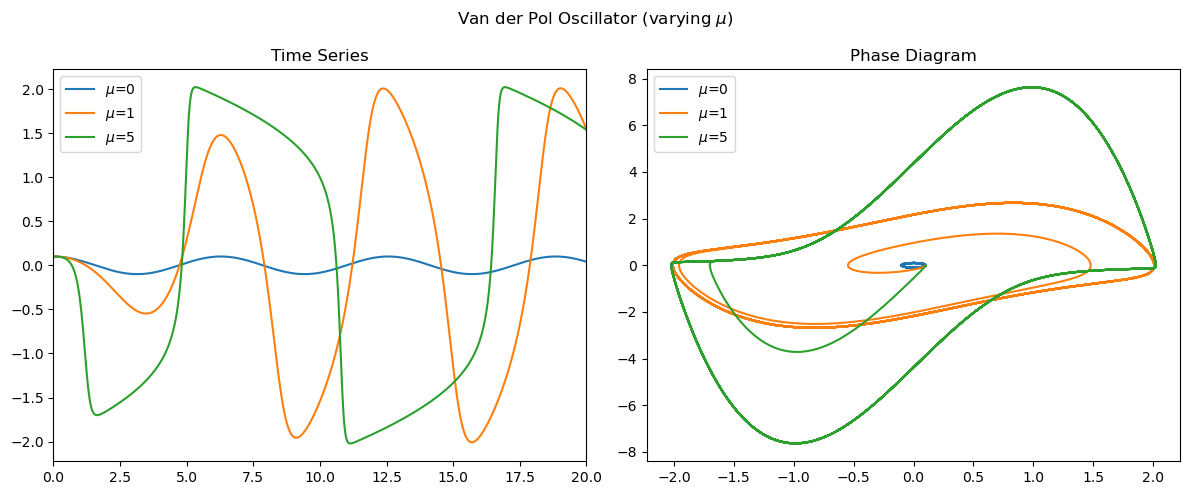

In [108]:
#parameters
mu_set = [0,1,5]

fig,axs = plt.subplots(1,2, figsize=(12,5))

for mu in mu_set:
    def func(x, yvals):
        y0,y1 = yvals #x,p
        f0 = y1
        f1 = mu*(1-y0**2)*y1-y0
        return np.array([f0,f1], dtype = np.float64)

    a,b,n = 0,100,10000
    yinits = np.array([0.1, 0], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    axs[0].plot(xs, ys[:, 0], label=fr"$\mu$={mu}")
    axs[0].set_xlim(0,20)
    axs[1].plot(ys[:, 0], ys[:, 1], label=fr"$\mu$={mu}")

plt.suptitle(r"Van der Pol Oscillator (varying $\mu$)")

axs[0].set_title("Time Series")
axs[1].set_title("Phase Diagram")

for ax in axs:
    ax.legend()

plt.tight_layout()
plt.show()

In [109]:
#Exercise 2: Lorentz equations

In [110]:
#parameters

sigma = 10
beta = 8/3
rho = 28

sigma_set = [1,5,sigma]
rho_set = [1,10,rho]
beta_set = [0.5,beta,4]

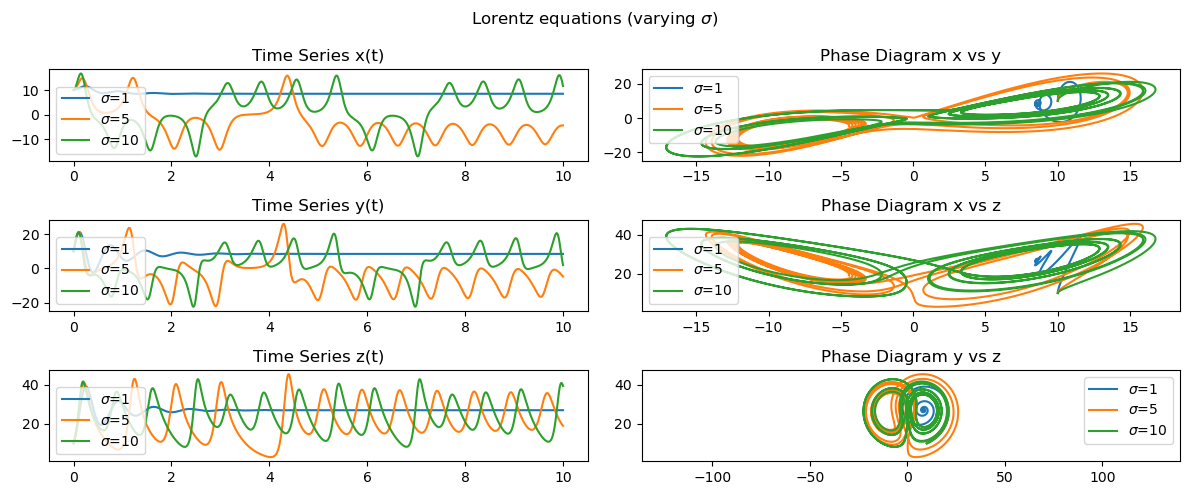

In [111]:
#Varying sigma
fig,axs = plt.subplots(3,2, figsize=(12,5))

for sigma in sigma_set:
    def func(t, yvals, sigma = sigma):
        x,y,z = yvals
        f0 = sigma*(y-x)
        f1 = x*(rho-z)-y
        f2 = x*y-beta*z
        return np.array([f0,f1,f2])

    a,b,n = 0,10,20000
    yinits = np.array([10, 10, 10], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    #Time Series
    axs[0,0].plot(xs, ys[:, 0], label=fr"$\sigma$={sigma}")
    axs[1,0].plot(xs, ys[:, 1], label=fr"$\sigma$={sigma}")
    axs[2,0].plot(xs, ys[:, 2], label=fr"$\sigma$={sigma}")

    #Phase Diagram
    axs[0,1].plot(ys[:, 0], ys[:, 1], label=fr"$\sigma$={sigma}")
    axs[1,1].plot(ys[:, 0], ys[:, 2], label=fr"$\sigma$={sigma}")
    axs[2,1].plot(ys[:, 1], ys[:, 2], label=fr"$\sigma$={sigma}")

plt.suptitle(r"Lorentz equations (varying $\sigma$)")

axs[0,0].set_title("Time Series x(t)")
axs[1,0].set_title("Time Series y(t)")
axs[2,0].set_title("Time Series z(t)")

axs[0,1].set_title("Phase Diagram x vs y")
axs[1,1].set_title("Phase Diagram x vs z")
axs[2,1].set_title("Phase Diagram y vs z")

for row in axs:
    for ax in row:
        ax.legend()

plt.tight_layout()
plt.axis('equal')
plt.show()

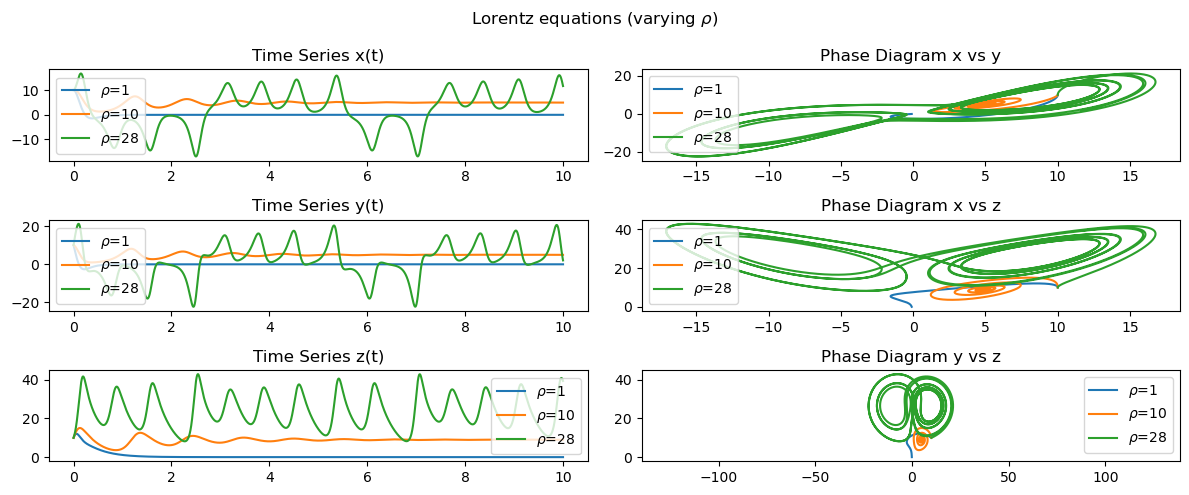

In [112]:
#varying rho
fig,axs = plt.subplots(3,2, figsize=(12,5))

for rho in rho_set:
    def func(x, yvals, rho = rho):
        x,y,z = yvals
        f0 = sigma*(y-x)
        f1 = x*(rho-z)-y
        f2 = x*y-beta*z
        return np.array([f0,f1,f2])

    a,b,n = 0,10,10000
    yinits = np.array([10, 10, 10], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    #Time Series
    axs[0,0].plot(xs, ys[:, 0], label=fr"$\rho$={rho}")
    axs[1,0].plot(xs, ys[:, 1], label=fr"$\rho$={rho}")
    axs[2,0].plot(xs, ys[:, 2], label=fr"$\rho$={rho}")

    #Phase Diagram
    axs[0,1].plot(ys[:, 0], ys[:, 1], label=fr"$\rho$={rho}")
    axs[1,1].plot(ys[:, 0], ys[:, 2], label=fr"$\rho$={rho}")
    axs[2,1].plot(ys[:, 1], ys[:, 2], label=fr"$\rho$={rho}")

plt.suptitle(r"Lorentz equations (varying $\rho$)")

axs[0,0].set_title("Time Series x(t)")
axs[1,0].set_title("Time Series y(t)")
axs[2,0].set_title("Time Series z(t)")

axs[0,1].set_title("Phase Diagram x vs y")
axs[1,1].set_title("Phase Diagram x vs z")
axs[2,1].set_title("Phase Diagram y vs z")

for row in axs:
    for ax in row:
        ax.legend()

plt.tight_layout()
plt.axis('equal')
plt.show()

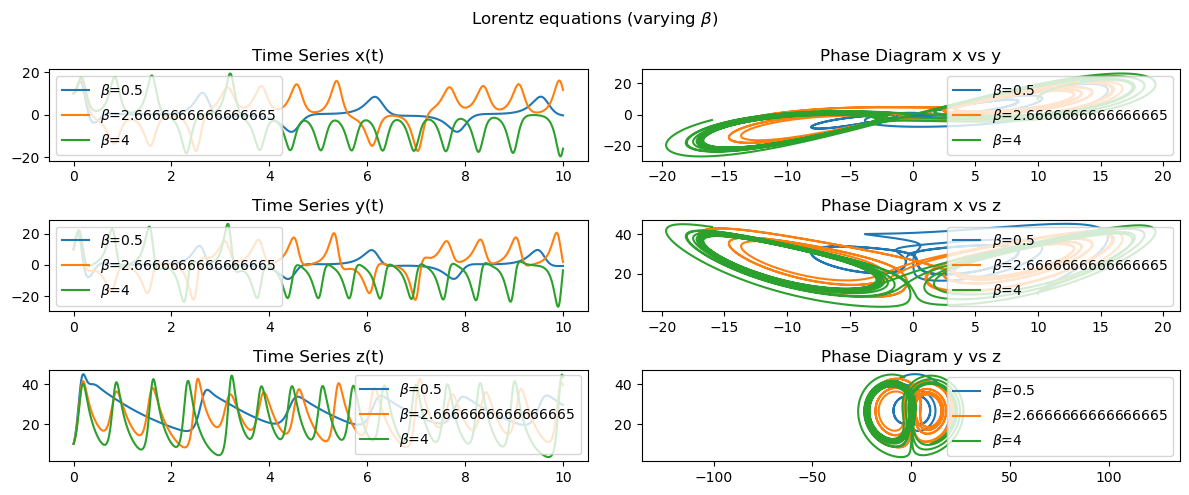

In [113]:
#varying beta
fig,axs = plt.subplots(3,2, figsize=(12,5))

for beta in beta_set:
    def func(x, yvals, beta = beta):
        x,y,z = yvals
        f0 = sigma*(y-x)
        f1 = x*(rho-z)-y
        f2 = x*y-beta*z
        return np.array([f0,f1,f2])

    a,b,n = 0,10,10000
    yinits = np.array([10, 10, 10], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    #Time series
    axs[0,0].plot(xs, ys[:, 0], label=fr"$\beta$={beta}")
    axs[1,0].plot(xs, ys[:, 1], label=fr"$\beta$={beta}")
    axs[2,0].plot(xs, ys[:, 2], label=fr"$\beta$={beta}")

    #Phase diagrtam
    axs[0,1].plot(ys[:, 0], ys[:, 1], label=fr"$\beta$={beta}")
    axs[1,1].plot(ys[:, 0], ys[:, 2], label=fr"$\beta$={beta}")
    axs[2,1].plot(ys[:, 1], ys[:, 2], label=fr"$\beta$={beta}")

plt.suptitle(r"Lorentz equations (varying $\beta$)")

axs[0,0].set_title("Time Series x(t)")
axs[1,0].set_title("Time Series y(t)")
axs[2,0].set_title("Time Series z(t)")

axs[0,1].set_title("Phase Diagram x vs y")
axs[1,1].set_title("Phase Diagram x vs z")
axs[2,1].set_title("Phase Diagram y vs z")

for row in axs:
    for ax in row:
        ax.legend()

plt.tight_layout()
plt.axis('equal')
plt.show()

In [87]:
#Exercise 3: Chua's circuit

In [88]:
#parameters

c1 = 15.6
c2 = 1.0
c3 = 28.0
m0 = -1.143
m1 = -0.714

c1_set = [8.0,10.0,c1,20.0]
c2_set = [0.5,0.7,c2,1.4]
c3_set = [10.0,20.0,c3,35.0]
m0_set = [-0.5,-0.9,m0,-1.3]
m1_set = [-0.2,-0.5,m1,-0.9]

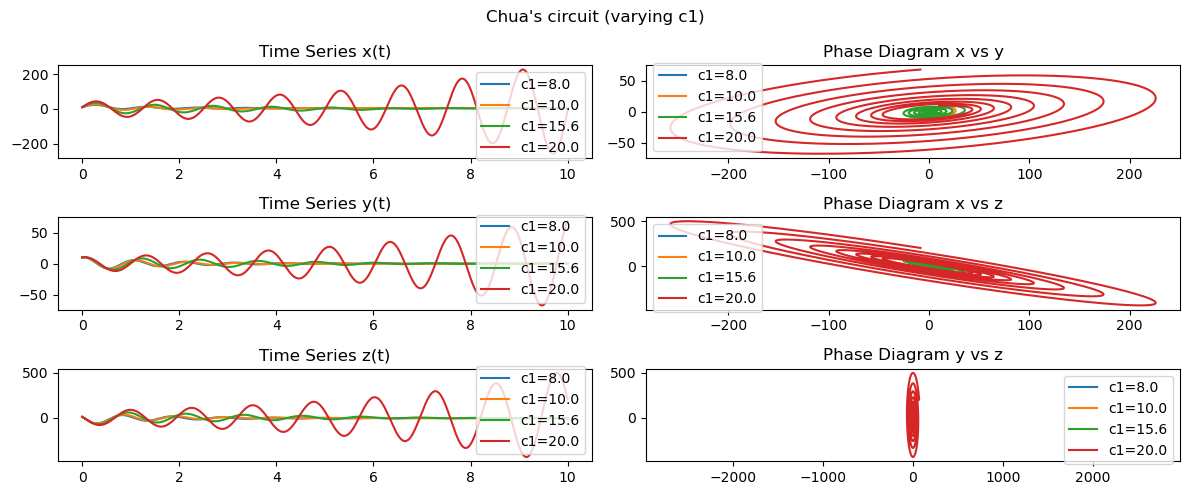

In [96]:
#Varying c1
fig,axs = plt.subplots(3,2, figsize = (12,5))

for c1 in c1_set:
    def func(t,yvals,c1=c1):
        x,y,z = yvals
        
        f_x = m1*x+(m0-m1)*(np.abs(x+1)-np.abs(x-1))/2
    
        f0 = c1*(y-x-f_x)
        f1 = c2*(x-y+z)
        f2 = -c3*y
        return np.array([f0,f1,f2])

    a,b,n = 0,10,10000
    yinits = np.array([10,10,10], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    #Time Series
    axs[0,0].plot(xs, ys[:, 0], label=f"c1={c1}")
    axs[1,0].plot(xs, ys[:, 1], label=f"c1={c1}")
    axs[2,0].plot(xs, ys[:, 2], label=f"c1={c1}")

    #Phase Diagram
    axs[0,1].plot(ys[:, 0], ys[:, 1], label=f"c1={c1}")
    axs[1,1].plot(ys[:, 0], ys[:, 2], label=f"c1={c1}")
    axs[2,1].plot(ys[:, 1], ys[:, 2], label=f"c1={c1}")

plt.suptitle("Chua's circuit (varying c1)")

axs[0,0].set_title("Time Series x(t)")
axs[1,0].set_title("Time Series y(t)")
axs[2,0].set_title("Time Series z(t)")

axs[0,1].set_title("Phase Diagram x vs y")
axs[1,1].set_title("Phase Diagram x vs z")
axs[2,1].set_title("Phase Diagram y vs z")

for row in axs:
    for ax in row:
        ax.legend()

plt.tight_layout()
plt.axis('equal')
plt.show()

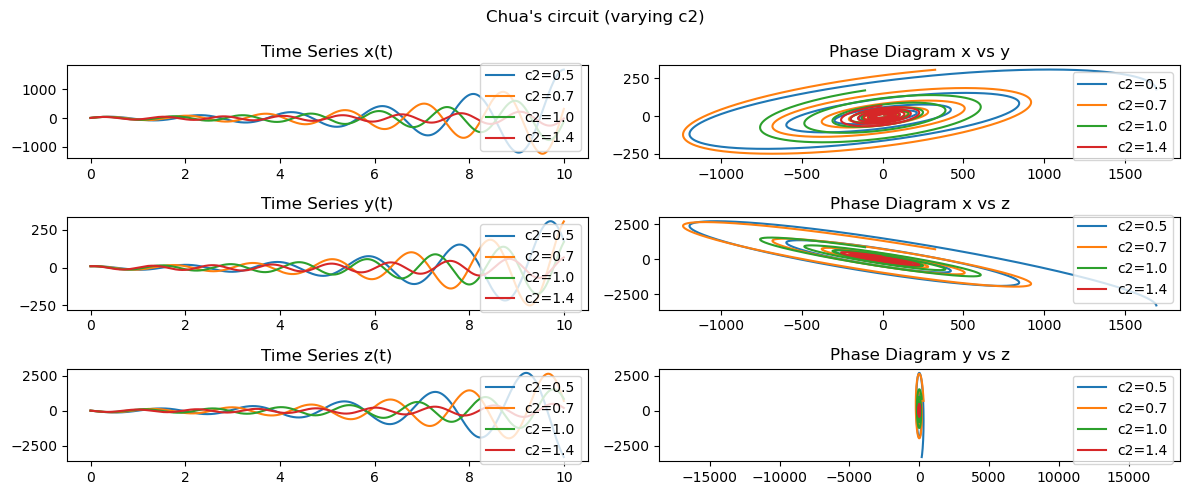

In [97]:
#Varying c2
fig,axs = plt.subplots(3,2, figsize = (12,5))

for c2 in c2_set:
    def func(t,yvals,c2=c2):
        x,y,z = yvals
        
        f_x = m1*x+(m0-m1)*(np.abs(x+1)-np.abs(x-1))/2
    
        f0 = c1*(y-x-f_x)
        f1 = c2*(x-y+z)
        f2 = -c3*y
        return np.array([f0,f1,f2])

    a,b,n = 0,10,10000
    yinits = np.array([10,10,10], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    #Time Series
    axs[0,0].plot(xs, ys[:, 0], label=f"c2={c2}")
    axs[1,0].plot(xs, ys[:, 1], label=f"c2={c2}")
    axs[2,0].plot(xs, ys[:, 2], label=f"c2={c2}")

    #Phase Diagram
    axs[0,1].plot(ys[:, 0], ys[:, 1], label=f"c2={c2}")
    axs[1,1].plot(ys[:, 0], ys[:, 2], label=f"c2={c2}")
    axs[2,1].plot(ys[:, 1], ys[:, 2], label=f"c2={c2}")

plt.suptitle("Chua's circuit (varying c2)")

axs[0,0].set_title("Time Series x(t)")
axs[1,0].set_title("Time Series y(t)")
axs[2,0].set_title("Time Series z(t)")

axs[0,1].set_title("Phase Diagram x vs y")
axs[1,1].set_title("Phase Diagram x vs z")
axs[2,1].set_title("Phase Diagram y vs z")

for row in axs:
    for ax in row:
        ax.legend()

plt.tight_layout()
plt.axis('equal')
plt.show()

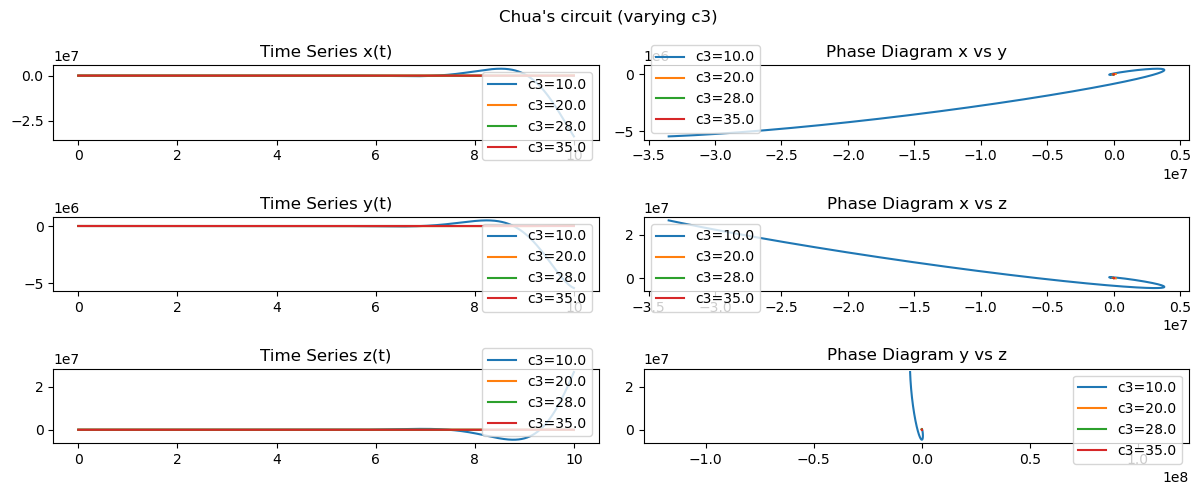

In [98]:
#Varying c3
fig,axs = plt.subplots(3,2, figsize = (12,5))

for c3 in c3_set:
    def func(t,yvals,c3=c3):
        x,y,z = yvals
        
        f_x = m1*x+(m0-m1)*(np.abs(x+1)-np.abs(x-1))/2
    
        f0 = c1*(y-x-f_x)
        f1 = c2*(x-y+z)
        f2 = -c3*y
        return np.array([f0,f1,f2])

    a,b,n = 0,10,10000
    yinits = np.array([10,10,10], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    #Time Series
    axs[0,0].plot(xs, ys[:, 0], label=f"c3={c3}")
    axs[1,0].plot(xs, ys[:, 1], label=f"c3={c3}")
    axs[2,0].plot(xs, ys[:, 2], label=f"c3={c3}")

    #Phase Diagram
    axs[0,1].plot(ys[:, 0], ys[:, 1], label=f"c3={c3}")
    axs[1,1].plot(ys[:, 0], ys[:, 2], label=f"c3={c3}")
    axs[2,1].plot(ys[:, 1], ys[:, 2], label=f"c3={c3}")

plt.suptitle("Chua's circuit (varying c3)")

axs[0,0].set_title("Time Series x(t)")
axs[1,0].set_title("Time Series y(t)")
axs[2,0].set_title("Time Series z(t)")

axs[0,1].set_title("Phase Diagram x vs y")
axs[1,1].set_title("Phase Diagram x vs z")
axs[2,1].set_title("Phase Diagram y vs z")

for row in axs:
    for ax in row:
        ax.legend()

plt.tight_layout()
plt.axis('equal')
plt.show()

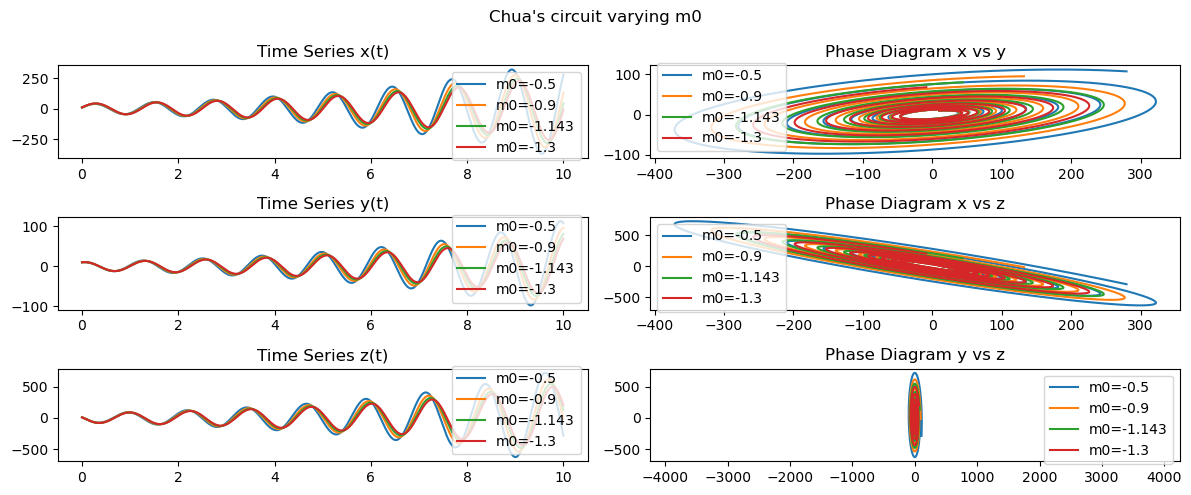

In [99]:
#Varying m0
fig,axs = plt.subplots(3,2, figsize = (12,5))

for m0 in m0_set:
    def func(t,yvals,m0=m0):
        x,y,z = yvals
        
        f_x = m1*x+(m0-m1)*(np.abs(x+1)-np.abs(x-1))/2
    
        f0 = c1*(y-x-f_x)
        f1 = c2*(x-y+z)
        f2 = -c3*y
        return np.array([f0,f1,f2])

    a,b,n = 0,10,10000
    yinits = np.array([10,10,10], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    #Time Series
    axs[0,0].plot(xs, ys[:, 0], label=f"m0={m0}")
    axs[1,0].plot(xs, ys[:, 1], label=f"m0={m0}")
    axs[2,0].plot(xs, ys[:, 2], label=f"m0={m0}")

    #Phase Diagram
    axs[0,1].plot(ys[:, 0], ys[:, 1], label=f"m0={m0}")
    axs[1,1].plot(ys[:, 0], ys[:, 2], label=f"m0={m0}")
    axs[2,1].plot(ys[:, 1], ys[:, 2], label=f"m0={m0}")

plt.suptitle("Chua's circuit varying m0")

axs[0,0].set_title("Time Series x(t)")
axs[1,0].set_title("Time Series y(t)")
axs[2,0].set_title("Time Series z(t)")

axs[0,1].set_title("Phase Diagram x vs y")
axs[1,1].set_title("Phase Diagram x vs z")
axs[2,1].set_title("Phase Diagram y vs z")

for row in axs:
    for ax in row:
        ax.legend()

plt.tight_layout()
plt.axis('equal')
plt.show()

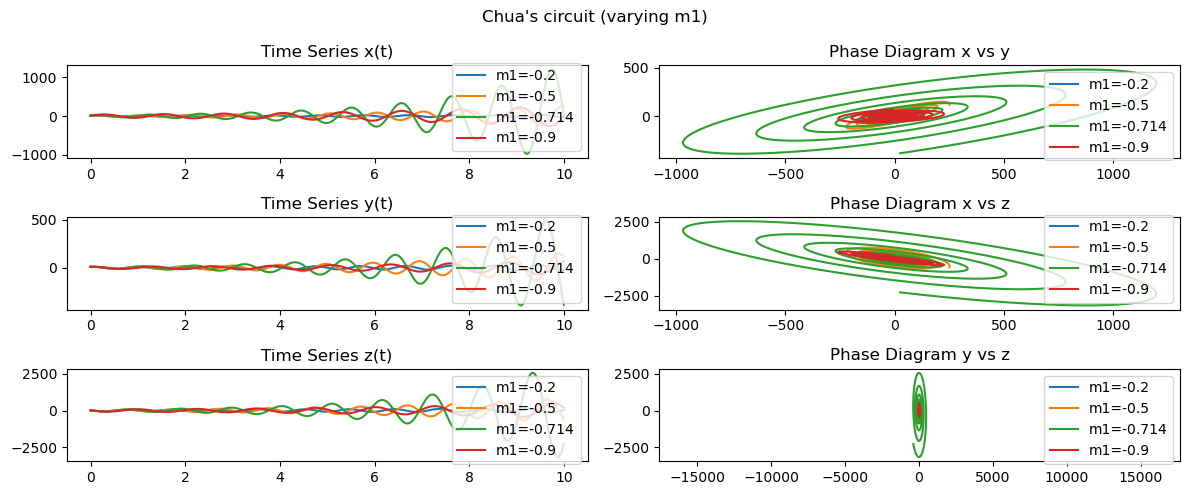

In [100]:
#Varying m1
fig,axs = plt.subplots(3,2, figsize = (12,5))

for m1 in m1_set:
    def func(t,yvals,m1=m1):
        x,y,z = yvals
        
        f_x = m1*x+(m0-m1)*(np.abs(x+1)-np.abs(x-1))/2
    
        f0 = c1*(y-x-f_x)
        f1 = c2*(x-y+z)
        f2 = -c3*y
        return np.array([f0,f1,f2])

    a,b,n = 0,10,10000
    yinits = np.array([10,10,10], dtype = np.float64)
    xs,ys = rk4_gen(func,a,b,n,yinits)

    #Time Series
    axs[0,0].plot(xs, ys[:, 0], label=f"m1={m1}")
    axs[1,0].plot(xs, ys[:, 1], label=f"m1={m1}")
    axs[2,0].plot(xs, ys[:, 2], label=f"m1={m1}")

    #Phase Diagram
    axs[0,1].plot(ys[:, 0], ys[:, 1], label=f"m1={m1}")
    axs[1,1].plot(ys[:, 0], ys[:, 2], label=f"m1={m1}")
    axs[2,1].plot(ys[:, 1], ys[:, 2], label=f"m1={m1}")

plt.suptitle("Chua's circuit (varying m1)")

axs[0,0].set_title("Time Series x(t)")
axs[1,0].set_title("Time Series y(t)")
axs[2,0].set_title("Time Series z(t)")

axs[0,1].set_title("Phase Diagram x vs y")
axs[1,1].set_title("Phase Diagram x vs z")
axs[2,1].set_title("Phase Diagram y vs z")

for row in axs:
    for ax in row:
        ax.legend()

plt.tight_layout()
plt.axis('equal')
plt.show()